# P2: Batt-P30K Morgan + XGBoost Baseline

This notebook demonstrates the full HDF5 -> SMILES -> Morgan -> XGBoost path and
then reads the formal full-data result. The smoke fit is intentionally small;
the authoritative result is `probes/p2_summary.json`.

The formal gate is **FAILED**: R2 is approximately 0.564, below the required 0.8.

In [1]:
import hashlib
import json
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

ROOT = Path.cwd()
if not (ROOT / "probes").exists():
    ROOT = ROOT.parent
h5_path = ROOT / "data" / "raw" / "batt" / "Batt-P30K.h5"
summary_path = ROOT / "probes" / "p2_summary.json"
assert h5_path.is_file(), h5_path
assert summary_path.is_file(), summary_path
digest = hashlib.sha256(h5_path.read_bytes()).hexdigest()
with h5py.File(h5_path, "r") as handle:
    group_count = len(handle)
print("Batt-P30K SHA256:", digest)
print("molecule groups:", group_count)

Batt-P30K SHA256: 587f1490613a008b91f45ee9de607a2e057c88c301fa9e5c9d7785b1968d118d
molecule groups: 29519


In [2]:
# Evenly sample the source so the smoke fit does not silently use only the first H5 block.
with h5py.File(h5_path, "r") as handle:
    keys = sorted(handle.keys(), key=lambda key: int(key.removeprefix("CompMol")))
    sample_indices = np.linspace(0, len(keys) - 1, num=min(3000, len(keys)), dtype=int)
    sample_keys = [keys[index] for index in sample_indices]
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
    X = []
    y = []
    invalid_smiles = 0
    for key in sample_keys:
        group = handle[key]
        raw_smiles = group["smiles"][0]
        smiles = raw_smiles.decode("utf-8") if isinstance(raw_smiles, bytes) else str(raw_smiles)
        molecule = Chem.MolFromSmiles(smiles)
        if molecule is None:
            invalid_smiles += 1
            continue
        X.append(generator.GetCountFingerprintAsNumPy(molecule))
        y.append(float(np.linalg.norm(np.asarray(group["dipole"][...], dtype=float))))
X = np.vstack(X).astype(np.float32)
y = np.asarray(y, dtype=np.float32)
print("smoke feature matrix:", X.shape)
print("invalid SMILES in smoke sample:", invalid_smiles)

smoke feature matrix: (3000, 2048)
invalid SMILES in smoke sample: 0


In [3]:
indices = np.random.default_rng(42).permutation(len(y))
test_count = max(1, round(0.2 * len(y)))
test_indices = indices[:test_count]
train_indices = indices[test_count:]
smoke_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=120,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.6,
    tree_method="hist",
    n_jobs=4,
    random_state=42,
)
smoke_model.fit(X[train_indices], y[train_indices])
prediction = smoke_model.predict(X[test_indices])
smoke_metrics = {
    "mae": float(mean_absolute_error(y[test_indices], prediction)),
    "rmse": float(np.sqrt(mean_squared_error(y[test_indices], prediction))),
    "r2": float(r2_score(y[test_indices], prediction)),
}
smoke_metrics

{'mae': 0.45562317967414856,
 'rmse': 0.5731886882609524,
 'r2': 0.3247847557067871}

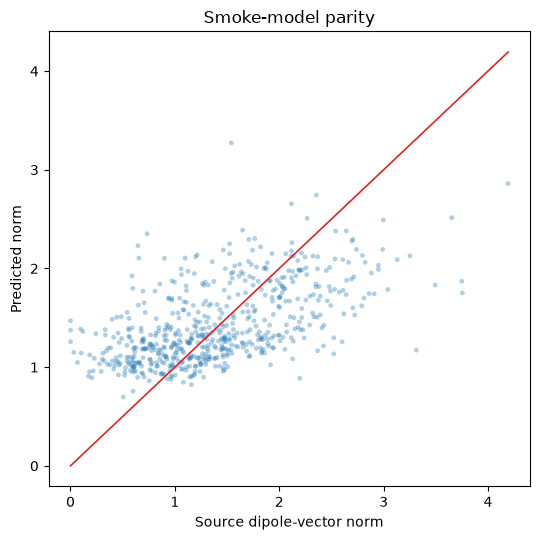

In [4]:
plt.figure(figsize=(5.5, 5.5))
plt.scatter(y[test_indices], prediction, s=12, alpha=0.35, edgecolors="none")
limit = float(max(np.max(y[test_indices]), np.max(prediction)))
plt.plot([0, limit], [0, limit], color="#dc2626", linewidth=1.2)
plt.xlabel("Source dipole-vector norm")
plt.ylabel("Predicted norm")
plt.title("Smoke-model parity")
plt.tight_layout()
plt.show()

In [5]:
formal = json.loads(summary_path.read_text(encoding="utf-8"))
print("Formal dataset SHA256:", formal["dataset_sha256"])
print("Formal molecules:", formal["molecule_count"])
print("Formal invalid SMILES:", formal["invalid_smiles_count"])
print("Formal cache status:", formal["feature_cache_status"])
print("Formal target units:", formal["target_units"])
print("Formal metrics:", formal["final_metrics"])
print("pass_r2_gt_0_8:", formal["pass_r2_gt_0_8"])

Formal dataset SHA256: 587f1490613a008b91f45ee9de607a2e057c88c301fa9e5c9d7785b1968d118d
Formal molecules: 29519
Formal invalid SMILES: 0
Formal cache status: rebuilt
Formal target units: not stated in the source README
Formal metrics: {'mae': 0.3600583076477051, 'rmse': 0.4895593928171895, 'r2': 0.5636486411094666}
pass_r2_gt_0_8: False


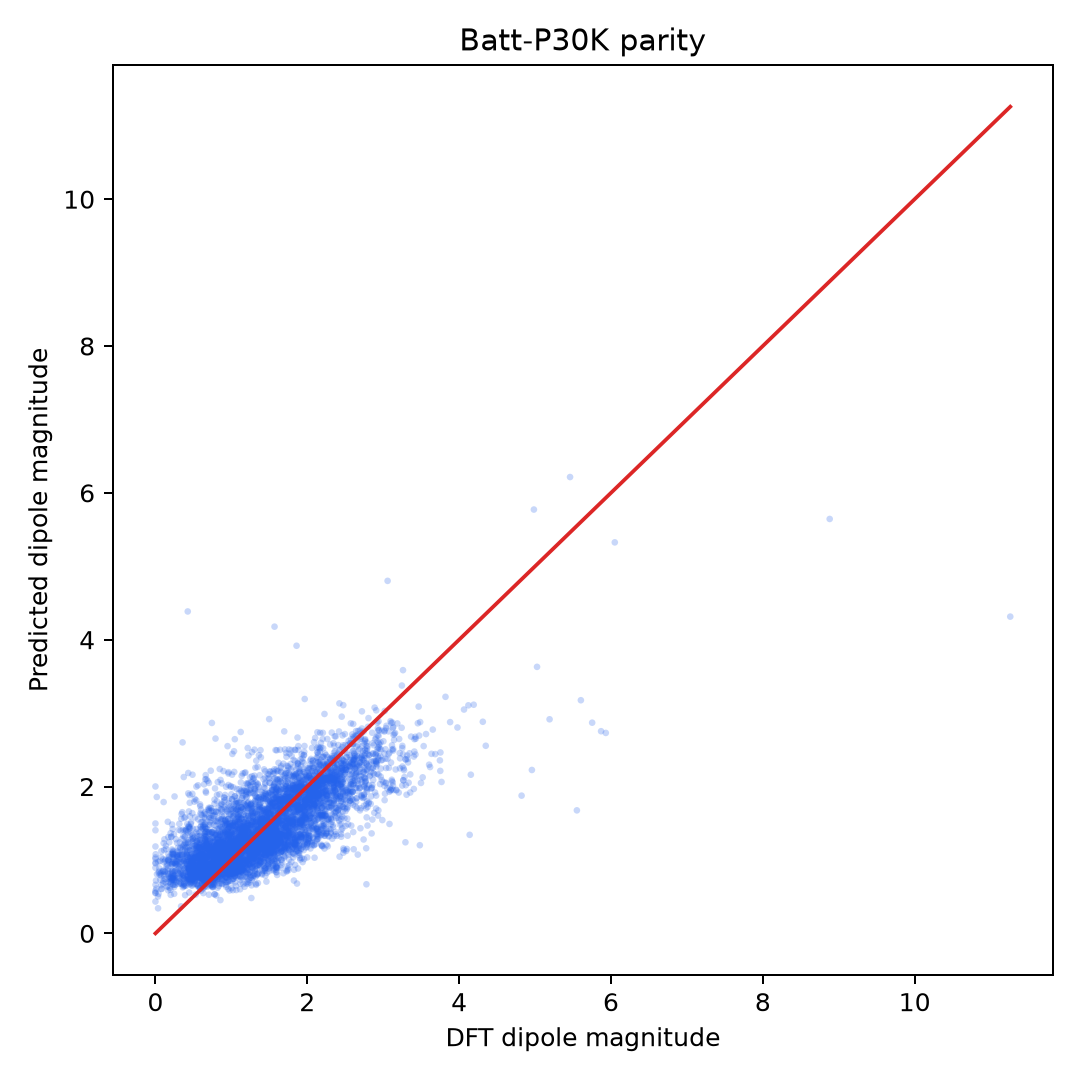

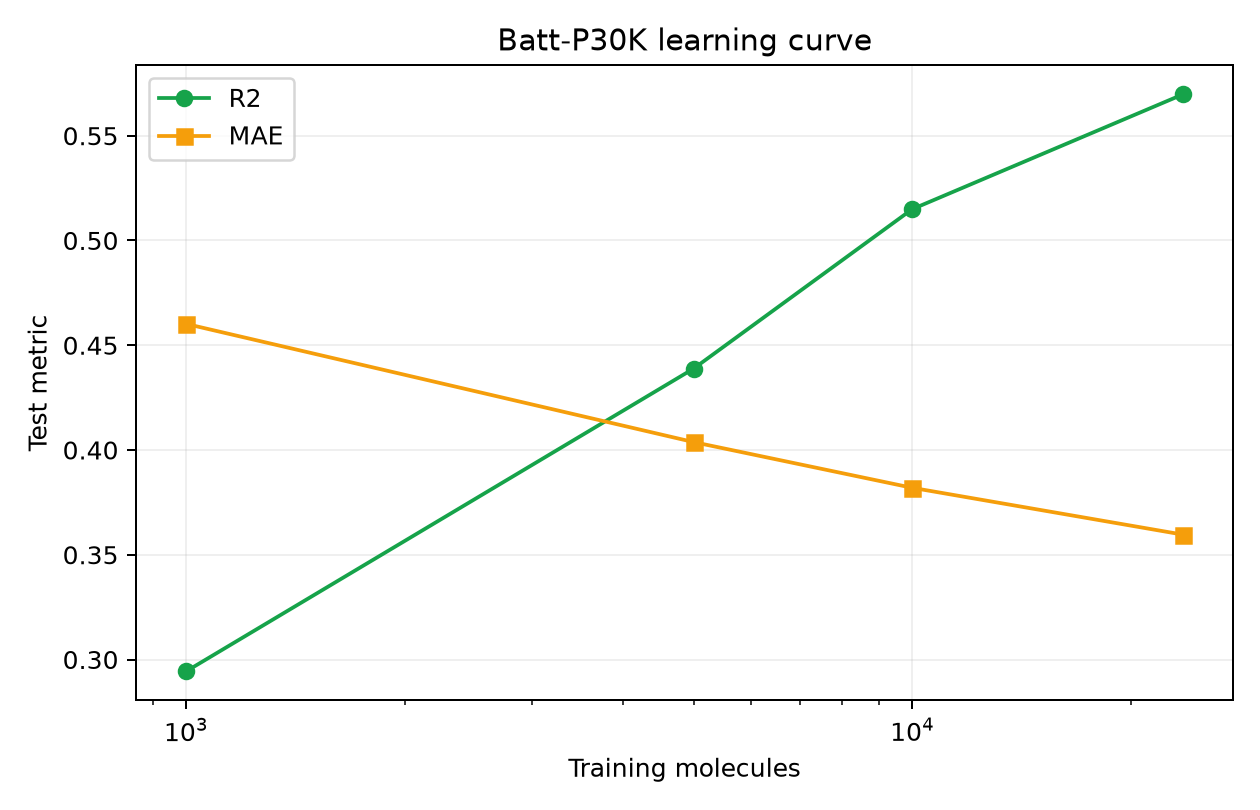

In [6]:
display(Image(filename=str(ROOT / "probes" / "artifacts" / "p2_dipole_parity.png")))
display(Image(filename=str(ROOT / "probes" / "artifacts" / "p2_dipole_learning_curve.png")))